# 00 — Run All

End-to-end notebook. Builds the LanceDB store (ingest + embeddings), runs both batch analyses (sentiment + topics), plots the results, and exposes an ad-hoc Q&A helper.

Run top-to-bottom. Every stage is resumable:
- **Ingest** skips files already seen (via `state/seen_files.json`).
- **Batches** skip entries already processed for the current `LLM_MODEL`.

Expected runtime on a cold run with `gemma3:4b`: ~25 min per batch. Re-runs only touch new entries, so they're fast.

## 1. Setup & ingest

Creates LanceDB tables and ingests any new `.html` entry files from `ENTRIES_DIR`. Embeddings come from `nomic-embed-text` via Ollama.

In [4]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from journal.config import ENTRIES_DIR, LANCE_ROOT, STATE_DIR
from journal.embed import OllamaEmbedder
from journal.ingest import Ingestor
from journal.store import Store

LANCE_ROOT.mkdir(parents=True, exist_ok=True)
STATE_DIR.mkdir(parents=True, exist_ok=True)

store = Store(LANCE_ROOT)
store.create_tables()

ingestor = Ingestor(
    store=store,
    embedder=OllamaEmbedder(),
    state_path=STATE_DIR / "seen_files.json",
)
report = ingestor.scan_and_ingest(ENTRIES_DIR)
print(report)

df = store.entries_to_pandas()
print(f"total entries: {len(df):,}")
print(f"date range: {df['date'].min()} → {df['date'].max()}")

IngestReport(files_processed=0, entries_added=0, files_skipped=1831, errors=[])
total entries: 3,035
date range: 2020-06-30 → 2026-06-22


### 2. Run sentiment batch

Resumable: entries already analyzed for `LLM_MODEL` are skipped automatically.

In [5]:
import json
from IPython.display import display

from journal.analyze import BatchAnalyzer, QuestionRegistry
from journal.config import LLM_MODEL
from journal.llm import OllamaLLM
from journal.questions.sentiment import SENTIMENT

reg = QuestionRegistry()
reg.register(SENTIMENT)
analyzer = BatchAnalyzer(
    store=store, llm=OllamaLLM(), registry=reg,
    model=LLM_MODEL, max_workers=6,
)
print(analyzer.run("sentiment"))

analyze[sentiment]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 495/495 [1:30:36<00:00, 10.98s/it]

AnalyzeReport(question_id='sentiment', processed=491, failed=4, errors=[])


## 3. Run topics batch

In [ ]:
from journal.questions.topics import TOPICS

reg = QuestionRegistry()
reg.register(TOPICS)
analyzer = BatchAnalyzer(
    store=store, llm=OllamaLLM(), registry=reg,
    model=LLM_MODEL, max_workers=6,
)
print(analyzer.run("topics"))

analyze[topics]:   0%|                                                                                                                                            | 0/2835 [00:04<?, ?it/s]


## 4. Sentiment plots

Distribution by day of week and time of day, plus weekly average score.

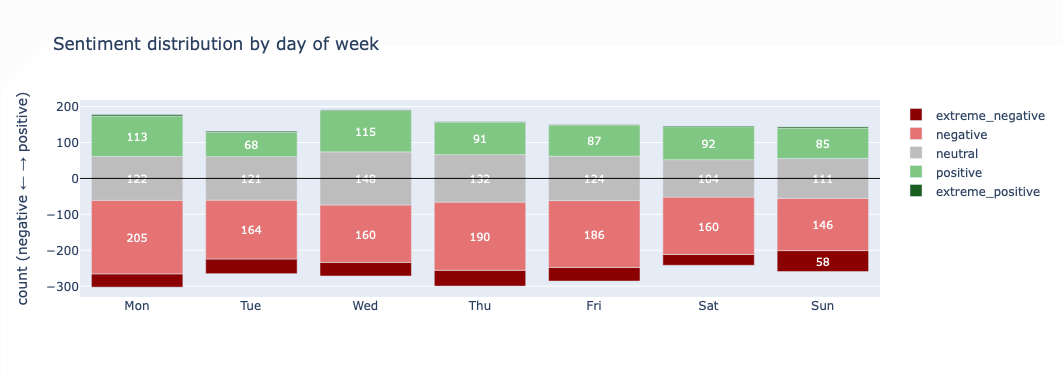

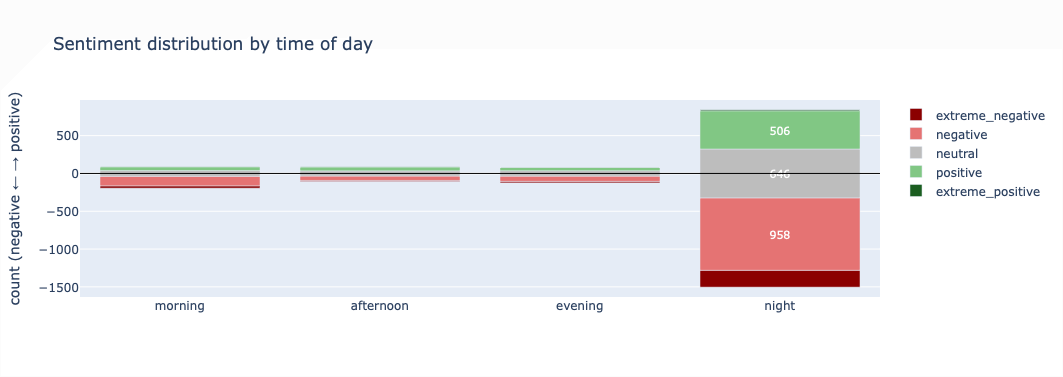

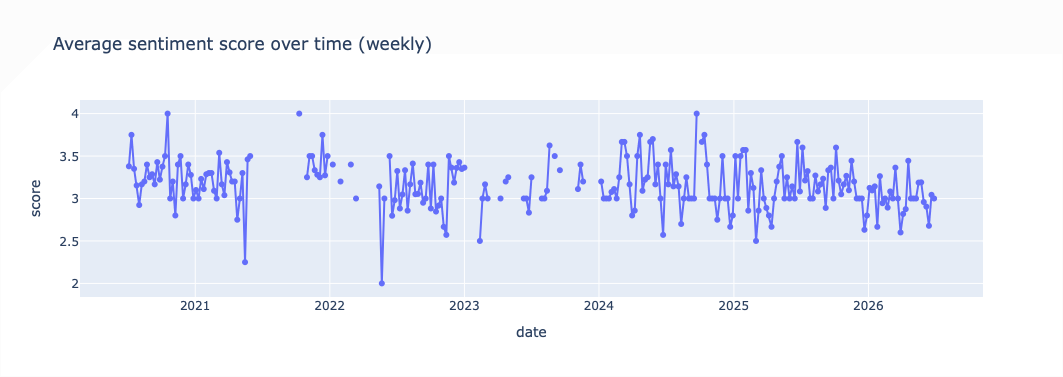

In [9]:
import plotly.graph_objects as go
import pandas as pd

order = ["extreme_negative", "negative", "neutral", "positive", "extreme_positive"]
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
tod_order = ["morning", "afternoon", "evening", "night"]

colors = {
    "extreme_negative": "#8B0000",
    "negative": "#E57373",
    "neutral": "#BDBDBD",
    "positive": "#81C784",
    "extreme_positive": "#1B5E20",
}

def diverging_sentiment_bar(data, group_col, group_order, title):
    ct = data.groupby([group_col, "level"]).size().reset_index(name="count")
    piv = (ct.pivot(index=group_col, columns="level", values="count")
             .reindex(index=group_order, columns=order, fill_value=0))

    half_neutral = piv["neutral"] / 2

    base_neg      = -(half_neutral + piv["negative"] + piv["extreme_negative"])
    base_negative = -(half_neutral + piv["negative"])
    base_neutral  = -half_neutral
    base_positive = half_neutral
    base_ex_pos   = half_neutral + piv["positive"]

    bases  = {"extreme_negative": base_neg, "negative": base_negative,
              "neutral": base_neutral, "positive": base_positive,
              "extreme_positive": base_ex_pos}
    counts = {lvl: piv[lvl] for lvl in order}

    fig = go.Figure()
    for level in order:
        c = counts[level]
        labels = c.apply(lambda v: str(v) if v > 0 else "")
        fig.add_trace(go.Bar(
            x=group_order, y=c, base=bases[level],
            name=level, marker_color=colors[level],
            customdata=c,
            text=labels, textposition="inside", insidetextanchor="middle",
            textfont=dict(color="white", size=11),
            hovertemplate="%{x}<br>" + level + ": %{customdata}<extra></extra>",
        ))

    fig.update_layout(
        barmode="overlay", title=title,
        xaxis=dict(categoryorder="array", categoryarray=group_order),
        yaxis_title="count (negative ← → positive)",
        uniformtext_minsize=9, uniformtext_mode="hide",  # hides labels that don't fit rather than overlapping
    )
    fig.add_hline(y=0, line_color="black", line_width=1)
    return fig

diverging_sentiment_bar(sdf, "day_of_week", day_order, "Sentiment distribution by day of week").show()
diverging_sentiment_bar(sdf, "time_of_day", tod_order, "Sentiment distribution by time of day").show()

sdf["date"] = pd.to_datetime(sdf["date"])
weekly = sdf.set_index("date")["score"].resample("W").mean().reset_index()
px.line(weekly, x="date", y="score", title="Average sentiment score over time (weekly)", markers=True).show()

## 5. Topics plots

Top topics overall, then the top-8 topics tracked monthly.

In [ ]:
t = a[(a["question_id"] == "topics") & a["parsed_ok"]].copy()
t["topics"] = t["result_json"].apply(lambda x: json.loads(x)["topics"])

exploded = t.explode("topics")
top = exploded["topics"].value_counts().head(30).reset_index()
top.columns = ["topic", "count"]
fig = px.bar(top, x="count", y="topic", orientation="h",
             title="Top 30 topics across all entries")
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

m = t.merge(df[["id", "date"]], left_on="entry_id", right_on="id")
m["date"] = pd.to_datetime(m["date"])
m = m.explode("topics")
top_topics = m["topics"].value_counts().head(8).index.tolist()
sub = m[m["topics"].isin(top_topics)]
freq = sub.groupby([sub["date"].dt.to_period("M"), "topics"]).size().reset_index(name="count")
freq["date"] = freq["date"].dt.to_timestamp()
px.line(freq, x="date", y="count", color="topics",
        title="Top topics over time (monthly)").show()

## 6. Ad-hoc Q&A

Vector-retrieves the `k` most relevant entries for a free-form question, then asks the LLM to answer with citations. Edit the questions or add your own.

In [ ]:
from IPython.display import Markdown
from journal.query import answer_question

def ask(question, k=10):
    result = answer_question(
        store=store,
        embedder=OllamaEmbedder(),
        llm=OllamaLLM(),
        question=question,
        k=k,
    )
    display(Markdown(f"### Q: {question}\n\n{result.answer}"))
    display(Markdown(f"**Sources ({len(result.sources)}):**"))
    for i, row in result.sources.iterrows():
        snippet = row["text"][:200].replace("\n", " ")
        display(Markdown(f"- [{i}] {row['date']} — {snippet}..."))

In [ ]:
ask("When did I feel most grateful, and what about?")

In [ ]:
ask("What were the recurring sources of stress in 2021?")

In [ ]:
ask("How did my relationship with my parents come up over the years?")